# Solutions

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.integrate
import scipy.optimize
import scipy.special
import time

## Shooting method for waves on a string

Found omega = 1.00001 pi, n = 0
Found omega = 2.00002 pi, n = 1
Found omega = 3.00003 pi, n = 2
Found omega = 4.00004 pi, n = 3
Found omega = 5.00005 pi, n = 4
Found omega = 6.00006 pi, n = 5


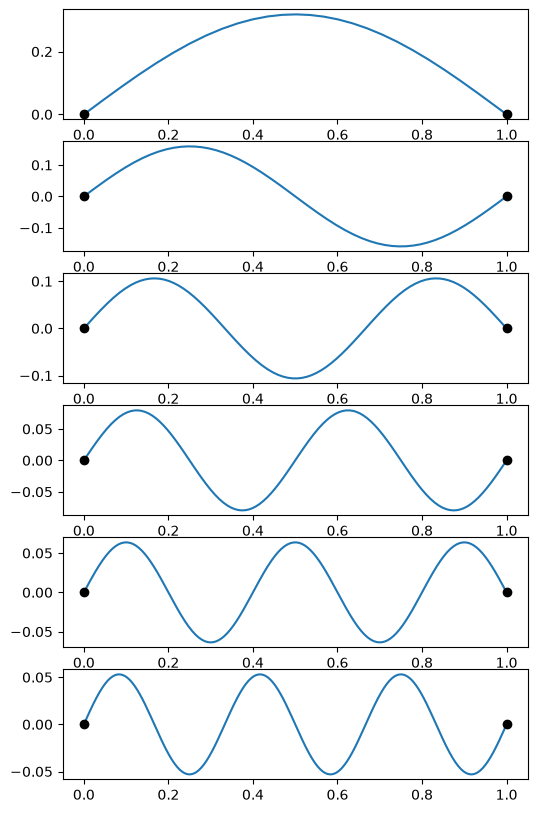

In [3]:
# First do the constant density string to check with the known frequencies
# and eigenfunctions

def derivs(x, y, omega):
    f, g = y
    dfdx = g
    rho = 1
    dgdx = - omega**2 * rho * f
    return dfdx, dgdx

def do_integration(omega):
    result = scipy.integrate.solve_ivp(derivs, (1e-5,1), (0,1), dense_output=True, args=(omega,), atol=1e-8, rtol=1e-8)
    return result.y[0,-1]

fig = plt.figure(figsize = (6,10))

# We'll take advantage of the known frequencies for this case to define the search windows
oms = np.pi * np.array((1,2,3,4,5,6))
num = len(oms)

for i, om in enumerate(oms):
    # search within 10% of the analytic frequency
    omega = scipy.optimize.brentq(do_integration, 0.9*om, 1.1*om)
    
    result = scipy.integrate.solve_ivp(derivs, (1e-5,1), (0,1), dense_output=True, args=(omega,), atol=1e-8, rtol=1e-8)
    x = result.t
    f = result.y[0]

    # find the number of zero crossings (not including the endpoints)
    n = ((f[1:-1] * f[:-2]) < 0).sum()
    print("Found omega = %lg pi, n = %d" % (omega/np.pi,n))

    plt.subplot(num,1,1+i)
    plt.plot(x, f)
    plt.plot((0,1),(0,0), 'ko')

plt.show()

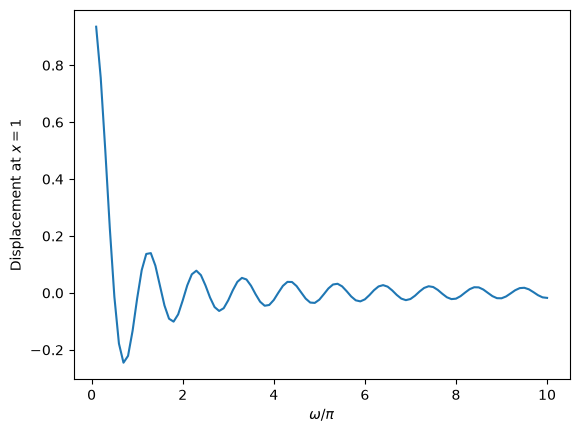

Frequency guesses= [0.4 1.  1.5 2.  2.5 3.  3.5 4.  4.6 5.1 5.6 6.1 6.6 7.1 7.6 8.1 8.7 9.2
 9.7]
Found omega = 0.493438 pi, n = 0
Found omega = 1.01755 pi, n = 1
Found omega = 1.53483 pi, n = 2
Found omega = 2.0489 pi, n = 3
Found omega = 2.56151 pi, n = 4
Found omega = 3.0735 pi, n = 5
Found omega = 3.58524 pi, n = 6
Found omega = 4.0969 pi, n = 7
Found omega = 4.60855 pi, n = 8
Found omega = 5.12021 pi, n = 9
Found omega = 5.63189 pi, n = 10
Found omega = 6.14359 pi, n = 11
Found omega = 6.65531 pi, n = 12
Found omega = 7.16705 pi, n = 13
Found omega = 7.67879 pi, n = 14
Found omega = 8.19055 pi, n = 15
Found omega = 8.70232 pi, n = 16
Found omega = 9.2141 pi, n = 17
Found omega = 9.72588 pi, n = 18


<Figure size 640x480 with 0 Axes>

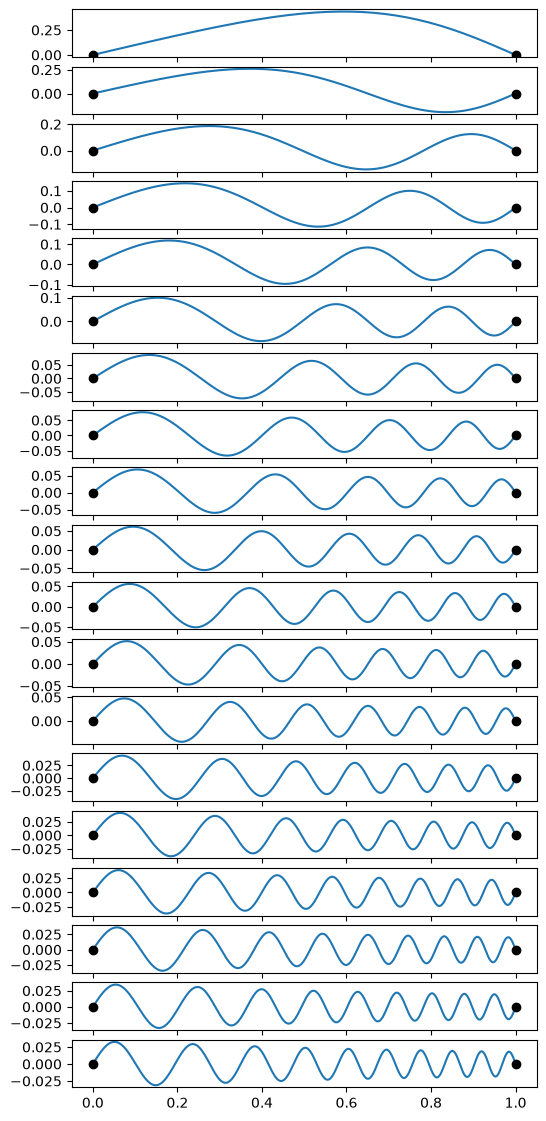

In [6]:
# Now do an x-dependent density
def rho(x):
    rho = 1.0 + 10*x**2
    #rho = np.ones_like(x)
    return rho

def derivs(x, y, omega):
    f, g = y
    dfdx = g
    dgdx = - omega**2 * rho(x) * f
    return dfdx, dgdx

def do_integration(omega):
    result = scipy.integrate.solve_ivp(derivs, (1e-5,1), (0,1), dense_output=True, args=(omega,), atol=1e-8, rtol=1e-8)
    return result.y[0,-1]

# Evaluate the displacement at x=1 on a grid of omega
oms = np.pi * np.linspace(0.1,10,100)
result = np.array([do_integration(om) for om in oms]) 
plt.plot(oms/np.pi, result)
plt.xlabel(r'$\omega/\pi$')
plt.ylabel(r'Displacement at $x=1$')
plt.show()
# identify the zero-crossings as initial guesses for mode frequencies
inds = np.where(np.diff(np.sign(result)))[0]
print('Frequency guesses=', oms[inds]/np.pi)

plt.clf()
num = len(inds)
fig = plt.figure(figsize = (6,14))

for i, ind in enumerate(inds):
    omega = scipy.optimize.brentq(do_integration, oms[ind], oms[ind+1])

    result = scipy.integrate.solve_ivp(derivs, (1e-5,1), (0,1), dense_output=True, args=(omega,), atol=1e-8, rtol=1e-8)
    x = result.t
    f = result.y[0]

    # find the number of zero crossings (not including the endpoints)
    n = ((f[1:-1] * f[:-2]) < 0).sum()
    print("Found omega = %lg pi, n = %d" % (omega/np.pi,n))

    plt.subplot(num,1,1+i)
    plt.plot(x, f)
    plt.plot((0,1),(0,0), 'ko')

plt.show()

# Store the last eigenfunction we found to compare later with the relaxation result
x_s = x
f_s = f
om_s = omega


## Relaxation method for waves on a string

In [40]:
def calculate_F(f, x, omega):
    F = np.zeros(ngrid)
    dx = x[1]-x[0]  # assume constant spacing    
    F[1:-1] = f[2:] - (2 - dx**2 * omega**2 * rho(x[1:-1]))*f[1:-1] + f[:-2]
    F[0] = f[0]  #bc
    F[-1] = f[-1] #bc
    return F

# Calculate the Jacobian in banded form
def calculate_J_banded(f, x, omega):
    dx = x[1]-x[0]  # assume constant spacing

    a = np.ones_like(x)
    a[0] = 0  # upper diagonal so don't need this
    a[1] = 0  # bc

    b = - (2 - dx**2 * omega**2 * rho(x))
    b[0] = 1  #bc
    b[-1] = 1 #bc
    
    c = np.ones_like(x)
    c[-2] = 0 # bc
    c[-1] = 0 # lower diagonal so don't need this
    
    return np.vstack((a,b,c))

F=1; Solve took 0.00041461 seconds
F=2.23952e-06; Solve took 0.000170469 seconds


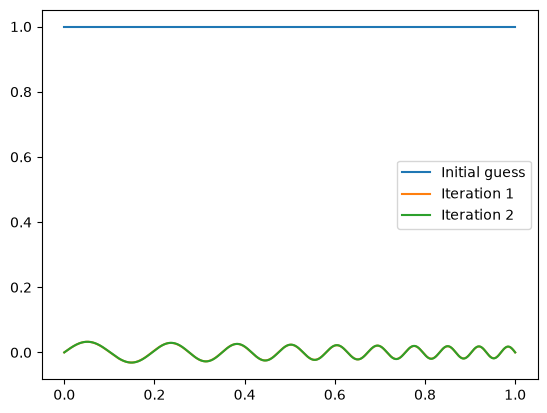

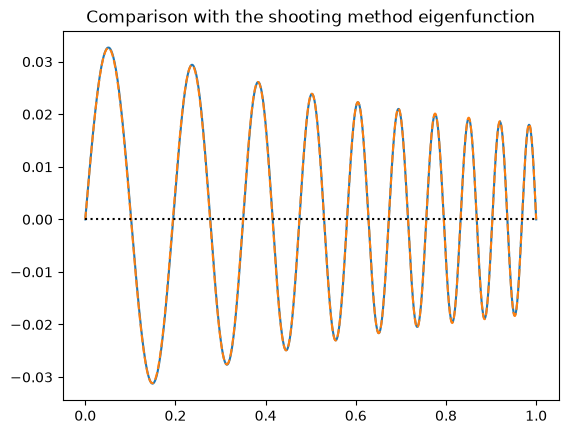

In [53]:
# Use the frequency from the shooting method:
omega = om_s
ngrid = 1000
x = np.linspace(0,1,ngrid)
dx = x[1]-x[0]

# Initial guess
f = np.ones_like(x)
plt.plot(x, f, label='Initial guess')

niter = 2
for m in range(niter):

    t0 = time.time()

    F = calculate_F(f, x, omega)
    J = calculate_J_banded(f, x, omega)
        
    df = -scipy.linalg.solve_banded((1,1), J, F)
    f = f + df

    # readjust normalization to keep df/dx=1 at x=0
    f = f * dx/ (f[1]-f[0])

    print('F=%lg; Solve took %lg seconds' % (max(abs(F)),time.time()-t0,))
    plt.plot(x, f, label='Iteration %d' % (m+1,))

plt.legend()
plt.show()

plt.clf()
plt.plot(x,f)
# compare with the analytic solution for constant density:
#plt.plot(x, np.sin(5 * np.pi * x), ":")
# compare with the shooting result:
plt.title('Comparison with the shooting method eigenfunction')
plt.plot(x_s, f_s, "--")
plt.plot((0,1),(0,0),"k:")
plt.show()